<a href="https://colab.research.google.com/github/j019/Practical-Machine-Learning-/blob/main/Day2/customerSegmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [160]:
from pandas import read_csv
import pandas as pd

Dataset : https://www.kaggle.com/datasets/carrie1/ecommerce-data

- Customer Segment Analysis
- Used KMeans Clustering
- Financial Analysis Based on Statistics

In [161]:
df = read_csv('/content/customer_data.csv', encoding='iso-8859-1')

In [162]:
df.shape

(541909, 8)

In [163]:
df.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [164]:
df.drop(columns=['Description'], inplace=True)

In [165]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [166]:
df.dropna(inplace=True)

In [167]:
df.shape

(406829, 7)

In [168]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Quantity', 'InvoiceDate', 'UnitPrice',
       'CustomerID', 'Country'],
      dtype='object')

In [169]:
df['Price'] = df['Quantity']*df['UnitPrice']

In [170]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Quantity', 'InvoiceDate', 'UnitPrice',
       'CustomerID', 'Country', 'Price'],
      dtype='object')

# Unique Invoices
- as_index = False or reset_index

In [171]:
df1 = df.groupby(['InvoiceNo','InvoiceDate','CustomerID'],as_index=False).agg({
    'Price': 'sum'})

In [172]:
df1.head()

,InvoiceNo,InvoiceDate,CustomerID,Price
0,536365,12/1/2010 8:26,17850.0,139.12
1,536366,12/1/2010 8:28,17850.0,22.20
2,536367,12/1/2010 8:34,13047.0,278.73
3,536368,12/1/2010 8:34,13047.0,70.05
4,536369,12/1/2010 8:35,13047.0,17.85


In [173]:
df1.shape

(22221, 4)

- CustomerId, total no of invoices, total spent
- std dev of spent in invoice
- days from the last invoice

In [174]:
df1= df1.loc[df1['Price'] > 0,:]

In [175]:
df1.shape

(18562, 4)

In [176]:
#df1['Total_Invoices'] = df1.groupby('CustomerID')['InvoiceNo'].transform('count')
#df1['Total_spent'] = df1.groupby('CustomerID')['Price'].transform('sum')
#df['Variance_spent'] = df1.groupby('CustomerID')['Price'].transform('std')
df2 = df1.groupby('CustomerID').agg({'Price':'sum','InvoiceNo':'count','InvoiceDate':'max'}).reset_index()

In [177]:
df2.head()

,CustomerID,Price,InvoiceNo,InvoiceDate
0,12346.0,77183.60,1,1/18/2011 10:01
1,12347.0,4310.00,7,8/2/2011 8:48
2,12348.0,1797.24,4,9/25/2011 13:13
3,12349.0,1757.55,1,11/21/2011 9:51
4,12350.0,334.40,1,2/2/2011 16:01


In [178]:
# Recency : Recent date from previous order
df2['Recency'] = pd.Timestamp.now() - pd.to_datetime(df2['InvoiceDate'])
df2['Recency'] = df2['Recency'].dt.days
df2.head()

,CustomerID,Price,InvoiceNo,InvoiceDate,Recency
0,12346.0,77183.60,1,1/18/2011 10:01,5633
1,12347.0,4310.00,7,8/2/2011 8:48,5437
2,12348.0,1797.24,4,9/25/2011 13:13,5382
3,12349.0,1757.55,1,11/21/2011 9:51,5326
4,12350.0,334.40,1,2/2/2011 16:01,5617


In [179]:
# Final Matrix
# drop -->  InvoiceDate
# rename --> Price : Monetary Gain
# rename --> InvoiceNo : Frequency

In [180]:
df2.drop(columns=['InvoiceDate'],inplace=True)
df2.rename(columns={'Price':'Monetary Gain','InvoiceNo':'Frequency'},inplace=True)


In [181]:
df2.head()

,CustomerID,Monetary Gain,Frequency,Recency
0,12346.0,77183.60,1,5633
1,12347.0,4310.00,7,5437
2,12348.0,1797.24,4,5382
3,12349.0,1757.55,1,5326
4,12350.0,334.40,1,5617


In [182]:
df2.shape

(4338, 4)

In [183]:
df2.set_index('CustomerID',inplace=True)

In [184]:
df2.columns

Index(['Monetary Gain', 'Frequency', 'Recency'], dtype='object')

In [185]:
X = df2

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [186]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
inertia_values = []
for k in range(2,11):
    mykmeans = KMeans(k,random_state=7)
    mykmeans.fit(X)
    inertia_values.append(mykmeans.inertia_)

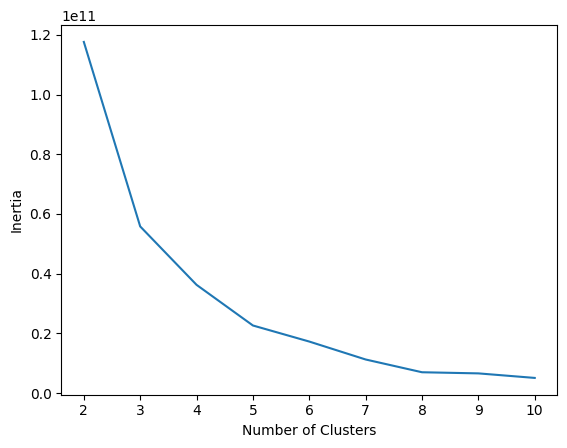

In [187]:
import matplotlib.pyplot as plt
plt.plot(list(range(2,11)), inertia_values)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [188]:
km = KMeans(n_clusters=3,random_state=7)
km.fit(X)
y_pred = km.predict(X)
print(silhouette_score(X,y_pred))

0.9540192783236692


# Financial Analysis Based on Statistics

- FMR metric is used
- F -> Frequency
- M -> Monetary Gain
- R -> Recency

 * Monetary Gain -> `high`
 * Monetary Gain -> *High & Frequency* -> `high`
 * Monetary Gain -> *Moderate & Frequency* -> `low`
 * Monetary Gain -> *High & Recency* -> `high`

In [189]:
# Divide data in Quartiles
# Monetary gain
# mg column -> 75% =< --> 1
#              50% - 75% --> 2
#              25% - 50% --> 3
#              25 > --> 4

In [190]:
def mg_calc(x):
  q1,q2,q3 = df2['Monetary Gain'].quantile([0.25,0.5,0.75])
  if x >= q3:
    return 1
  elif q2 <= x < q3:
    return 2
  elif q1 <= x < q2:
    return 3
  else:
    return 4
df2['MG'] = df2['Monetary Gain'].apply(mg_calc)

In [191]:
df2.head()

,Monetary Gain,Frequency,Recency,MG
CustomerID,,,,
12346.0,77183.60,1,5633,1
12347.0,4310.00,7,5437,1
12348.0,1797.24,4,5382,1
12349.0,1757.55,1,5326,1
12350.0,334.40,1,5617,3


In [192]:
def fq_calc(x):
  q1,q2,q3 = df2['Frequency'].quantile([0.25,0.5,0.75])
  if x >= q3:
    return 1
  elif q2 <= x < q3:
    return 2
  elif q1 <= x < q2:
    return 3
  else:
    return 4
df2['F'] = df2['Frequency'].apply(fq_calc)

In [193]:
def rc_calc(x):
  q1,q2,q3 = df2['Recency'].quantile([0.25,0.5,0.75])
  if x >= q3:
    return 4
  elif q2 <= x < q3:
    return 3
  elif q1 <= x < q2:
    return 2
  else:
    return 1
df2['R'] = df2['Recency'].apply(rc_calc)

In [194]:
df2.head()

,Monetary Gain,Frequency,Recency,MG,F,R
CustomerID,,,,,,
12346.0,77183.60,1,5633,1,3,4
12347.0,4310.00,7,5437,1,1,3
12348.0,1797.24,4,5382,1,2,2
12349.0,1757.55,1,5326,1,3,1
12350.0,334.40,1,5617,3,3,4
